In [1]:
# import relevant packages

import nrrd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [5]:
# main plotting funtion
def view_nrrd_slice(file_path, slice_index=None):

    """Reads an NRRD file and displays a single slice using matplotlib."""

    data, header = nrrd.read(file_path)

    print(f"Data shape: {data.shape}")
    print(f"Header info: {header}")

    # Determine the slice to display (default to middle slice of the last dimension)

    if slice_index is None:
        slice_index = data.shape[-1] // 2

    # Display the slice. Assuming the last dimension is the slice/depth axis.
    # Adjust indexing if your data dimensions are different.

    plt.imshow(data[:, slice_index, :], cmap='jet')
    plt.title(f"Slice {slice_index} of NRRD file")
    # plt.axis('off')
    plt.gca().invert_yaxis()
    plt.show()


Data shape: (138, 138, 138)
Header info: OrderedDict([('type', 'float'), ('dimension', 3), ('space', 'left-posterior-superior'), ('sizes', array([138, 138, 138])), ('space directions', array([[3., 0., 0.],
       [0., 3., 0.],
       [0., 0., 3.]])), ('kinds', ['domain', 'domain', 'domain']), ('endian', 'little'), ('encoding', 'raw'), ('space origin', array([-207., -207., -207.]))])


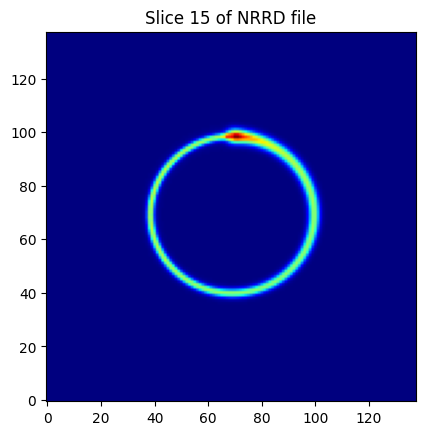

In [19]:
# Example usage:
view_nrrd_slice("/home/ubuntu/DoseCUDA-Jax/test_phantom_output/cube_impt_dose.nrrd", slice_index=15)

Data shape: (138, 138, 138)
Header info: OrderedDict([('type', 'float'), ('dimension', 3), ('space', 'left-posterior-superior'), ('sizes', array([138, 138, 138])), ('space directions', array([[3., 0., 0.],
       [0., 3., 0.],
       [0., 0., 3.]])), ('kinds', ['domain', 'domain', 'domain']), ('endian', 'little'), ('encoding', 'raw'), ('space origin', array([-207., -207., -207.]))])


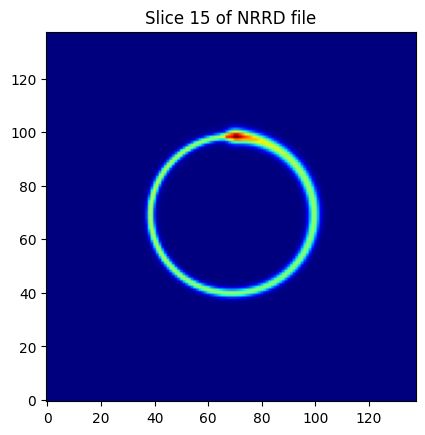

In [18]:
# Example usage:
view_nrrd_slice("/home/ubuntu/DoseCUDA-Jax/test_phantom_output/cube_impt_dose_jax.nrrd", slice_index=15)

Data shape: (161, 161, 112)
Header info: OrderedDict([('type', 'float'), ('dimension', 3), ('space', 'left-posterior-superior'), ('sizes', array([161, 161, 112])), ('space directions', array([[3., 0., 0.],
       [0., 3., 0.],
       [0., 0., 3.]])), ('kinds', ['domain', 'domain', 'domain']), ('endian', 'little'), ('encoding', 'raw'), ('space origin', array([-240.50999451, -240.77000427, -973.5       ]))])


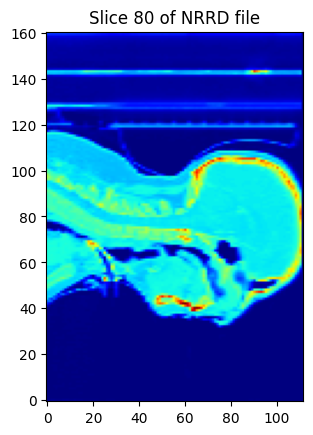

In [20]:
# HEAD_AND_NECK CT
view_nrrd_slice("/home/ubuntu/DoseCUDA-Jax/test_phantom_output/head_and_neck/ct.nrrd", slice_index=80)

Data shape: (161, 161, 112)
Header info: OrderedDict([('type', 'float'), ('dimension', 3), ('space', 'left-posterior-superior'), ('sizes', array([161, 161, 112])), ('space directions', array([[3., 0., 0.],
       [0., 3., 0.],
       [0., 0., 3.]])), ('kinds', ['domain', 'domain', 'domain']), ('endian', 'little'), ('encoding', 'raw'), ('space origin', array([-240.50999451, -240.77000427, -973.5       ]))])


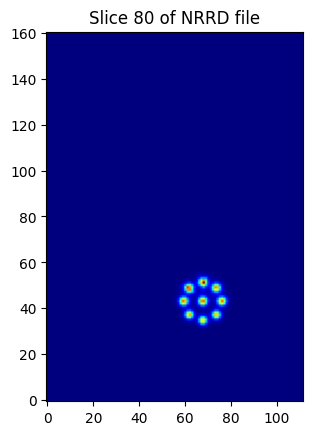

In [22]:
# HEAD_AND_NECK CUDA dose
view_nrrd_slice("/home/ubuntu/DoseCUDA-Jax/test_phantom_output/head_and_neck/dose_cuda.nrrd", slice_index=80)

Data shape: (161, 161, 112)
Header info: OrderedDict([('type', 'float'), ('dimension', 3), ('space', 'left-posterior-superior'), ('sizes', array([161, 161, 112])), ('space directions', array([[3., 0., 0.],
       [0., 3., 0.],
       [0., 0., 3.]])), ('kinds', ['domain', 'domain', 'domain']), ('endian', 'little'), ('encoding', 'raw'), ('space origin', array([-240.50999451, -240.77000427, -973.5       ]))])


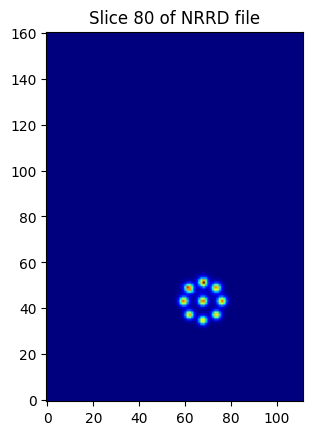

In [23]:
# HEAD_AND_NECK JAX dose
view_nrrd_slice("/home/ubuntu/DoseCUDA-Jax/test_phantom_output/head_and_neck/dose_jax.nrrd", slice_index=80)

CUDA shape: (161, 161, 112), JAX shape: (161, 161, 112)
CUDA max: 6.8705, JAX max: 6.8773


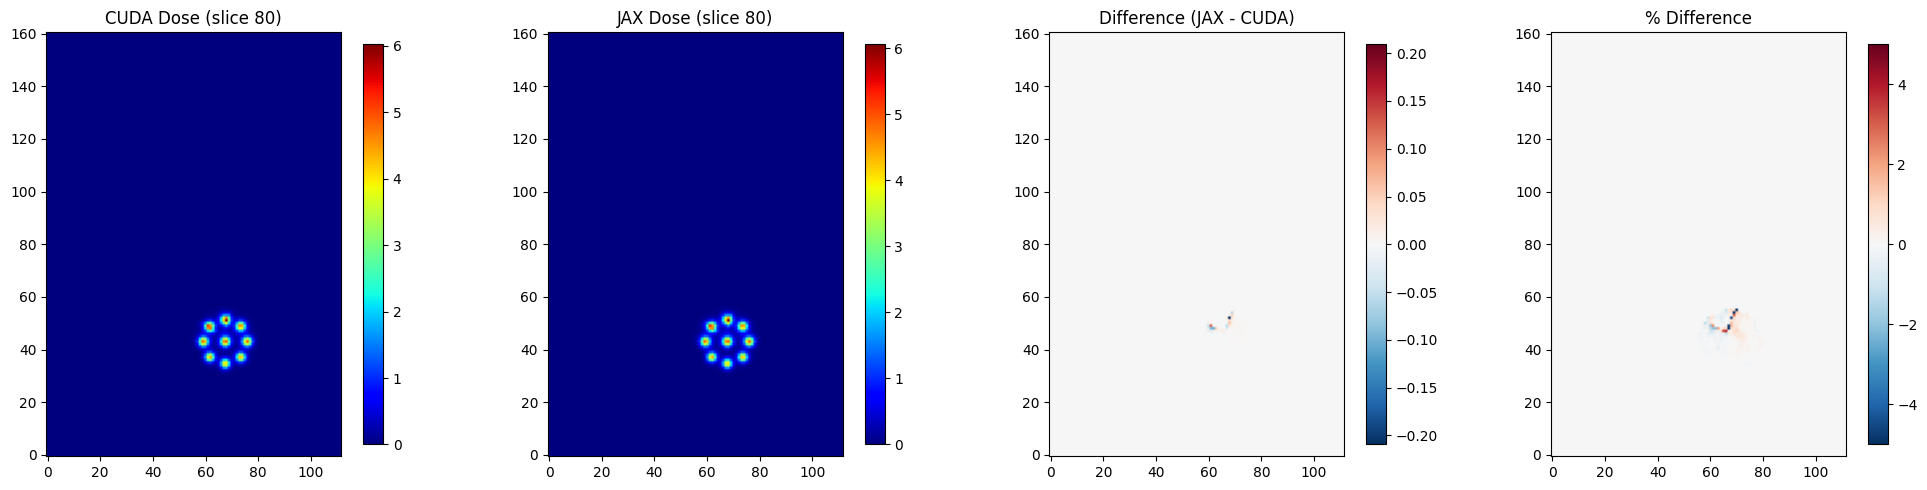

In [24]:
# Side-by-side comparison of CUDA vs JAX dose on HEAD_AND_NECK
def compare_doses_side_by_side(cuda_path, jax_path, slice_index=None):
    """Display CUDA and JAX doses side by side with difference."""
    
    cuda_data, cuda_header = nrrd.read(cuda_path)
    jax_data, jax_header = nrrd.read(jax_path)
    
    print(f"CUDA shape: {cuda_data.shape}, JAX shape: {jax_data.shape}")
    print(f"CUDA max: {cuda_data.max():.4f}, JAX max: {jax_data.max():.4f}")
    
    if slice_index is None:
        slice_index = cuda_data.shape[-1] // 2
    
    cuda_slice = cuda_data[:, slice_index, :]
    jax_slice = jax_data[:, slice_index, :]
    diff_slice = jax_slice - cuda_slice
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # CUDA
    im0 = axes[0].imshow(cuda_slice, cmap='jet')
    axes[0].set_title(f'CUDA Dose (slice {slice_index})')
    axes[0].invert_yaxis()
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    # JAX
    im1 = axes[1].imshow(jax_slice, cmap='jet')
    axes[1].set_title(f'JAX Dose (slice {slice_index})')
    axes[1].invert_yaxis()
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # Difference
    vmax = max(abs(diff_slice.min()), abs(diff_slice.max()))
    im2 = axes[2].imshow(diff_slice, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[2].set_title('Difference (JAX - CUDA)')
    axes[2].invert_yaxis()
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    # Percent difference (where CUDA > threshold)
    mask = cuda_slice > cuda_data.max() * 0.01
    pct_diff = np.zeros_like(diff_slice)
    pct_diff[mask] = 100 * diff_slice[mask] / cuda_slice[mask]
    im3 = axes[3].imshow(pct_diff, cmap='RdBu_r', vmin=-5, vmax=5)
    axes[3].set_title('% Difference')
    axes[3].invert_yaxis()
    plt.colorbar(im3, ax=axes[3], fraction=0.046)
    
    plt.tight_layout()
    plt.show()
    
compare_doses_side_by_side(
    "/home/ubuntu/DoseCUDA-Jax/test_phantom_output/head_and_neck/dose_cuda.nrrd",
    "/home/ubuntu/DoseCUDA-Jax/test_phantom_output/head_and_neck/dose_jax.nrrd",
    slice_index=80
)